In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '/data/gusev/USERS/jpconnor/data/CAIA/COMPASS/'
baca_df = pd.read_csv(
    os.path.join(DATA_PATH, 'baca_lab_patient_annotations.tsv'),
    sep="\t",
    encoding="utf-8",
    encoding_errors="replace")
text_df = pd.read_csv(os.path.join(DATA_PATH, 'prostate_text_data.csv'))

/tmp/ipykernel_194922/2570720732.py:12: DtypeWarning: Columns (1,5,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  text_df = pd.read_csv(os.path.join(DATA_PATH, 'prostate_text_data.csv'))


/tmp/ipykernel_194922/2366828476.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'] = np.abs(pd.to_datetime(just_NEPC_baca_df['MEDICATION_START_TIME']) - pd.to_datetime(just_NEPC_baca_df['NEPC_DIAG_DATE']))
/tmp/ipykernel_194922/2366828476.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'] = np.abs(pd.to_datetime(just_NEPC_baca_df['MEDICATION_START_TIME']) - pd.to_datetime(just_NEPC_baca_df['NEPC_DIAG_DATE']))
/tmp/ipykernel_194922/2366828476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

(array([9., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([ 20. ,  82.3, 144.6, 206.9, 269.2, 331.5, 393.8, 456.1, 518.4,
        580.7, 643. ]),
 <BarContainer object of 10 artists>)

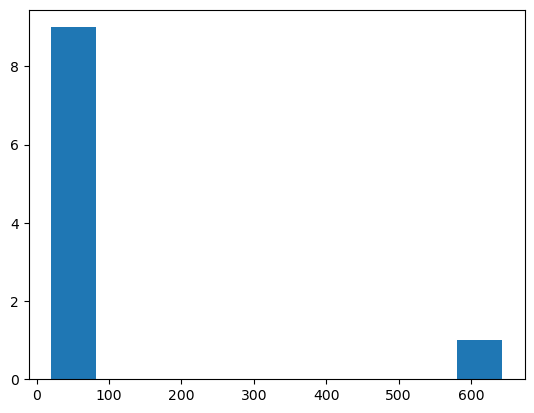

In [16]:
just_NEPC_baca_df = baca_df.loc[~baca_df['NEPC_DIAG_DATE'].isna()]
just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'] = np.abs(pd.to_datetime(just_NEPC_baca_df['MEDICATION_START_TIME']) - pd.to_datetime(just_NEPC_baca_df['NEPC_DIAG_DATE']))
just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'] = just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'].apply(lambda x : x.days)
plt.hist(just_NEPC_baca_df['TIME_BETWEEN_MED_AND_NEPC_DIAG'])

In [18]:
candidate_patients = baca_df.loc[baca_df['Inidcation of Platinum Therapy'].isna(), 
                                 ['DFCI_MRN', 'PLATINUM_CHEMO_MED', 'MEDICATION_START_TIME']]
len(candidate_patients['DFCI_MRN'].unique())

160

In [19]:
len(baca_df['DFCI_MRN'].unique())

202

In [20]:
LLM_text_df = text_df.merge(candidate_patients, on='DFCI_MRN', how='inner')
event_dt = pd.to_datetime(LLM_text_df['EVENT_DATE'], errors='coerce', utc=True)
med_dt = pd.to_datetime(LLM_text_df['MEDICATION_START_TIME'], errors='coerce', utc=True)

LLM_text_df['NOTE_TIME_REL_PLATINUM_START'] = event_dt - med_dt
LLM_text_df['NOTE_TIME_REL_PLATINUM_START'] = LLM_text_df['NOTE_TIME_REL_PLATINUM_START'].apply(lambda x : x.days)

/tmp/ipykernel_194922/2384055891.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  med_dt = pd.to_datetime(LLM_text_df['MEDICATION_START_TIME'], errors='coerce', utc=True)


In [21]:
len(LLM_text_df)

27157

In [26]:
candidate_LLM_text_df = LLM_text_df.loc[np.abs(LLM_text_df['NOTE_TIME_REL_PLATINUM_START']) <= 90]

In [28]:
len(candidate_LLM_text_df['DFCI_MRN'].unique())

157

In [7]:
candidate_LLM_text_df.sort_values(by='DFCI_MRN')

,PROC_DESC_STR,PROVIDER_CRED_STR,EVENT_DATE,id,DFCI_MRN,ENCOUNTER_TYPE_DESC_STR,RPT_DATE,RPT_TYPE,SOURCE_STR,PROVIDER_CRED,CLINICAL_TEXT,NOTE_TYPE,PLATINUM_CHEMO_MED,MEDICATION_START_TIME,NOTE_TIME_REL_PLATINUM_START
19960,Progress Note,NaN,2018-04-23T21:27:00Z,194881358702,234767,Documentation,NaN,Progress Note,Other,NaN,Call with Mr and Mrs Smith to discuss his scan...,Clinician,CARBOPLATIN,1/24/18 12:26,89
20018,Progress Note,RN,2018-02-20T19:30:00Z,186924704602,234767,Infusion,NaN,Progress Note,Other,RN,Pt presents to infusion for Day 1 Cycle 2 of t...,Clinician,CARBOPLATIN,1/24/18 12:26,27
19843,Progress Note,RN,2018-01-02T20:30:00Z,180993890902,234767,Infusion,NaN,Progress Note,Other,RN,Pt presents to infusion for Day 1 Cycle 3 of t...,Clinician,CARBOPLATIN,1/24/18 12:26,-22
19857,Progress Note,MD,2018-01-02T19:45:00Z,180923264002,234767,Office Visit,NaN,Progress Note,Other,MD,DFCI GU ONCOLOGY PROGRESS NOTE Mr. James Smith...,Clinician,CARBOPLATIN,1/24/18 12:26,-22
20375,Progress Note,NP,2018-03-19T16:00:00Z,190285291302,234767,Office Visit,NaN,Progress Note,Other,NP,DFCI GU ONCOLOGY PROGRESS NOTE Mr. James Smith...,Clinician,CARBOPLATIN,1/24/18 12:26,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27054,Progress Note,NaN,2023-10-18T21:59:00Z,1066191684702,1151114,Social Work,NaN,Progress Note,Other,NaN,Social Work Progress Note Date/Time of contact...,Clinician,CARBOPLATIN,9/27/23 13:38,21
27065,Progress Note,NaN,2023-11-06T20:02:00Z,1077605003202,1151114,Social Work,NaN,Progress Note,Other,NaN,Social Work Progress Note Date/Time of contact...,Clinician,CARBOPLATIN,9/27/23 13:38,40
27071,Progress Note,RN,2023-11-08T20:30:00Z,1079754883802,1151114,Infusion,NaN,Progress Note,Other,RN,Pt here for C3 D1 Cabazitaxel/Carbo. VSS. Labs...,Clinician,CARBOPLATIN,9/27/23 13:38,42
27074,Progress Note,NaN,2023-11-09T05:58:00Z,1079838785502,1151114,Documentation,NaN,Progress Note,Other,NaN,Calvin Innerarity was consented to Protocol 23...,Clinician,CARBOPLATIN,9/27/23 13:38,42
